# Home Loan Default Risk Management

##  Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

## Data Loading

In [3]:
df = pd.read_csv('../data/application_train.csv')

## Data Understanding

In [4]:
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print("Shape:", df.shape)

df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [7]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [8]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
df.shape

(307511, 122)

 The dataset contains 307,510 records and 122 features. Each record represents a loan application submitted by a customer.

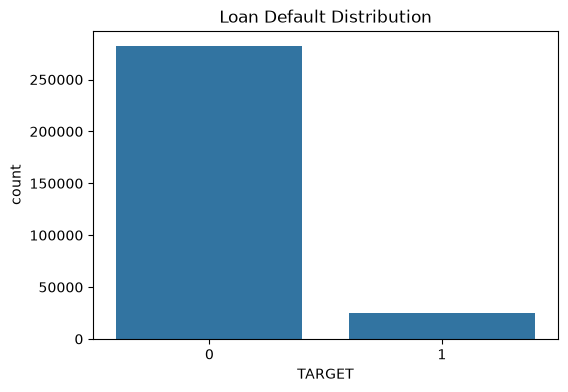

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title('Loan Default Distribution')
plt.show()

In [11]:
target_percent = df['TARGET'].value_counts(normalize=True) * 100
print(target_percent)

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64



The dataset is highly imbalanced, with approximately 91.92% non-defaulters and 8.08% defaulters.

##  Missing Value Analysis

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)

In [13]:
missing_percent = (df.isnull().sum()/len(df)) * 100

In [14]:
missing_percent

SK_ID_CURR                     0.000000
TARGET                         0.000000
NAME_CONTRACT_TYPE             0.000000
CODE_GENDER                    0.000000
FLAG_OWN_CAR                   0.000000
                                ...    
AMT_REQ_CREDIT_BUREAU_DAY     13.501631
AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
AMT_REQ_CREDIT_BUREAU_MON     13.501631
AMT_REQ_CREDIT_BUREAU_QRT     13.501631
AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
Length: 122, dtype: float64

In [15]:
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
}).sort_values('Percentage', ascending=False)


In [16]:
missing_df.head(20)

,Missing Values,Percentage
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


##  Data Cleaning

In [17]:
cols_to_drop = missing_percent[missing_percent>60 ].index
print("Columns to drop:", len(cols_to_drop))

Columns to drop: 17


In [18]:
df = df.drop(columns = cols_to_drop)

In [19]:
df.shape

(307511, 105)

Several variables contained a very high percentage of missing values. Columns with more than 60% missing observations were removed because imputing such a large proportion of data could introduce significant bias and reduce model reliability.

This approach helped reduce dimensionality and improve data quality while retaining the most informative features.

In [20]:
df.select_dtypes(include='object').columns.tolist()

C:\Users\91706\AppData\Local\Temp\ipykernel_25632\3152244773.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns.tolist()


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [21]:
df.select_dtypes(include='object').columns.to_list()

C:\Users\91706\AppData\Local\Temp\ipykernel_25632\2516629603.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns.to_list()


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [22]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts().head())

C:\Users\91706\AppData\Local\Temp\ipykernel_25632\126348761.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:



NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree         

In [23]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts().head())


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER


C:\Users\91706\AppData\Local\Temp\ipykernel_25632\126348761.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Name: count, dtype: int64

NAME_INCOME_TYPE
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Name: count, dtype: int64

NAME_EDUCATION_TYPE
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

NAME_FAMILY_STATUS
NAME_FAMILY_STATUS
Married                 196432
Single / not marri

In [24]:
remaining_missing = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

remaining_missing.head(20)

LANDAREA_AVG          59.376738
LANDAREA_MODE         59.376738
LANDAREA_MEDI         59.376738
BASEMENTAREA_AVG      58.515956
BASEMENTAREA_MODE     58.515956
BASEMENTAREA_MEDI     58.515956
EXT_SOURCE_1          56.381073
NONLIVINGAREA_AVG     55.179164
NONLIVINGAREA_MODE    55.179164
NONLIVINGAREA_MEDI    55.179164
ELEVATORS_AVG         53.295980
ELEVATORS_MODE        53.295980
ELEVATORS_MEDI        53.295980
WALLSMATERIAL_MODE    50.840783
APARTMENTS_MODE       50.749729
APARTMENTS_MEDI       50.749729
APARTMENTS_AVG        50.749729
ENTRANCES_AVG         50.348768
ENTRANCES_MODE        50.348768
ENTRANCES_MEDI        50.348768
dtype: float64

In [25]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\91706\AppData\Local\Temp\ipykernel_25632\2165584795.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [27]:
df.isnull().sum().sum()

np.int64(0)

In [28]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
cat_cols = df.select_dtypes(include='object').columns

print("Categorical columns:", len(cat_cols))
print(cat_cols)


Categorical columns: 15
Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')


C:\Users\91706\AppData\Local\Temp\ipykernel_25632\538415225.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [30]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 105 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(49), int64(56)
memory usage: 246.3 MB


##  Exploratory Data Analysis

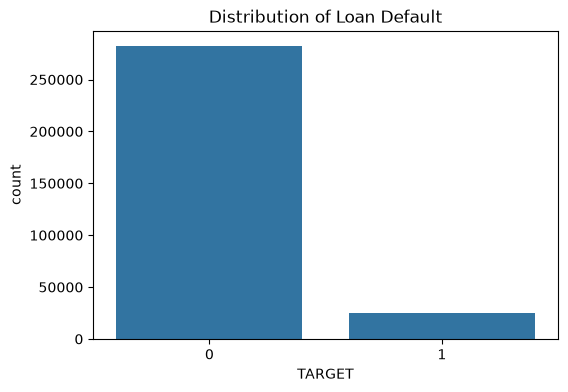

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title('Distribution of Loan Default')
plt.show()

Observation:

- The dataset is highly imbalanced.
- Approximately 92% of applicants are non-defaulters.
- Around 8% of applicants are defaulters.
- Special attention should be given during model building to handle class imbalance.

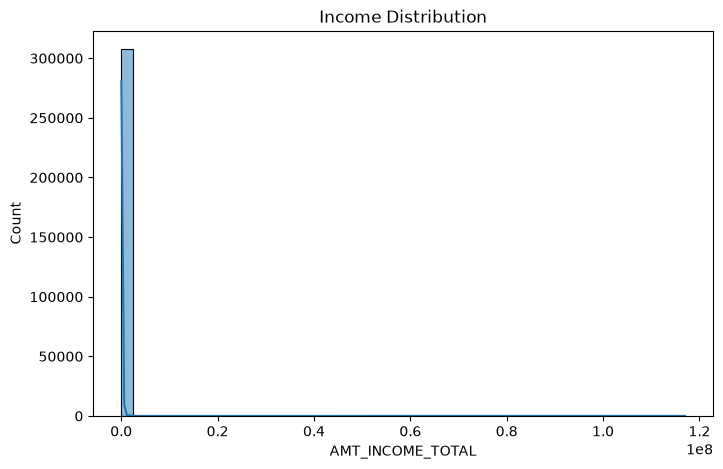

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(df['AMT_INCOME_TOTAL'], bins=50, kde=True)
plt.title('Income Distribution')
plt.show()

Observation:

- The income distribution is highly right-skewed.
- Most applicants fall within a relatively lower income range.
- A small number of applicants have extremely high incomes, creating significant outliers.
- These outliers compress the visualization and may require outlier treatment or transformation during modeling.

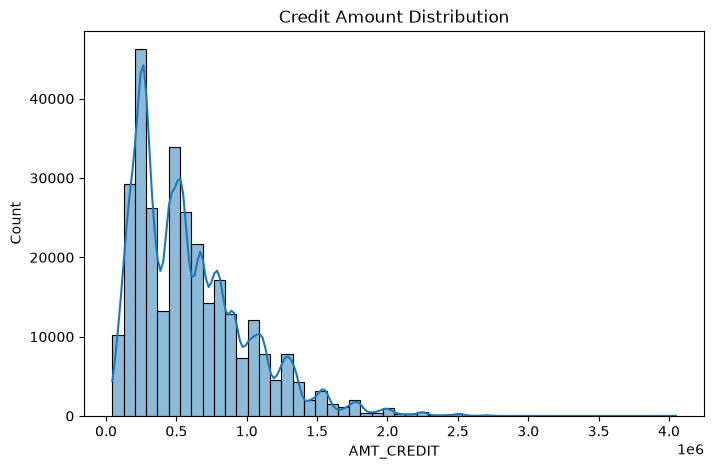

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['AMT_CREDIT'], bins=50, kde=True)
plt.title('Credit Amount Distribution')
plt.show()

Observation:

- Credit amounts are positively skewed.
- Most loans are concentrated between lower and medium credit ranges.
- The number of applicants decreases as the credit amount increases.
- Very high credit loans are relatively rare.

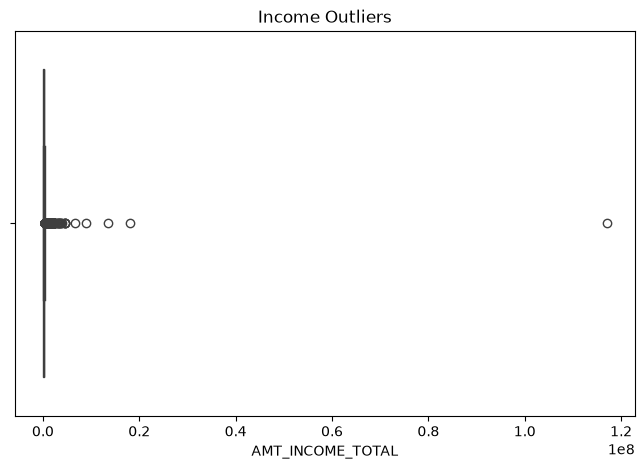

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['AMT_INCOME_TOTAL'])
plt.title('Income Outliers')
plt.show()

C:\Users\91706\AppData\Local\Temp\ipykernel_25632\3898992106.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365


<Axes: xlabel='AGE_YEARS', ylabel='Count'>

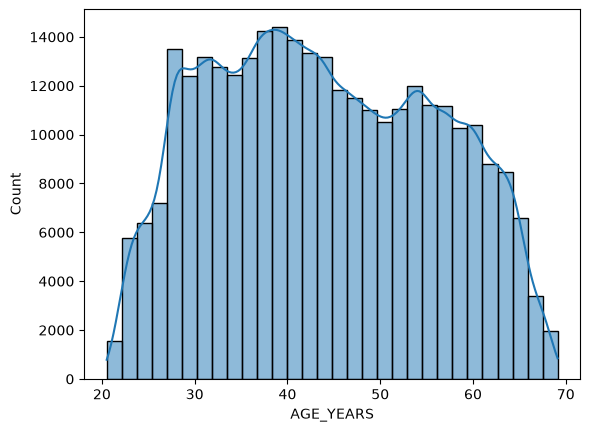

In [36]:
# Age Distribution
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

sns.histplot(df['AGE_YEARS'], bins=30, kde=True)

### Observation

- The age distribution indicates that most loan applicants are between 30 and 60 years old.
- Very young applicants constitute a smaller proportion of the dataset.
- The distribution suggests that middle-aged individuals are the primary customer segment for home loans.
- Age may play an important role in assessing repayment capacity and default risk.

<Axes: xlabel='TARGET', ylabel='AMT_INCOME_TOTAL'>

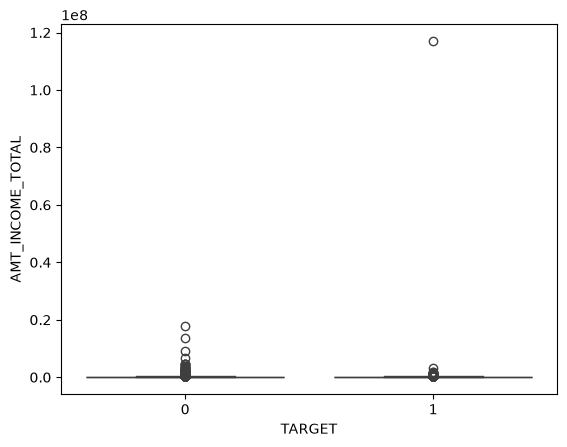

In [37]:
# Income vs Default
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)

### Observation

- The income distribution of both defaulters and non-defaulters shows significant variation.
- Several extreme income outliers are present in both categories.
- Most applicants, regardless of default status, belong to lower and middle-income groups.
- Income alone may not be sufficient to distinguish defaulters from non-defaulters and should be evaluated alongside other financial indicators.

<Axes: xlabel='CODE_GENDER', ylabel='count'>

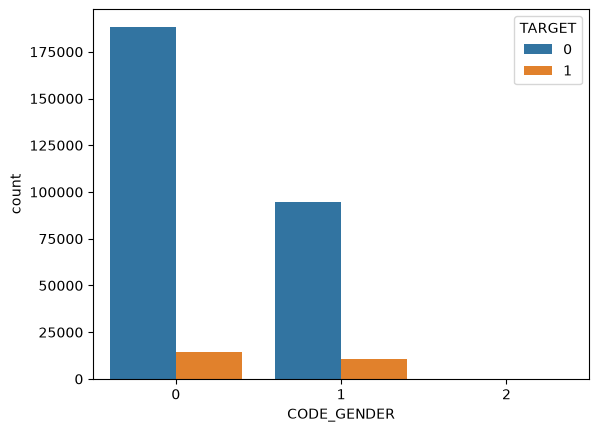

In [38]:
# Gender vs Default
sns.countplot(x='CODE_GENDER', hue='TARGET', data=df)

### Observation

- The dataset contains both male and female applicants, with one category having a noticeably higher number of applications.
- Non-defaulters dominate across both gender groups due to the overall class imbalance in the dataset.
- Differences in default counts between genders can provide insights into customer risk profiles.
- Gender may contribute to loan default prediction when combined with other demographic and financial variables.

([0, 1, 2, 3, 4],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4')])

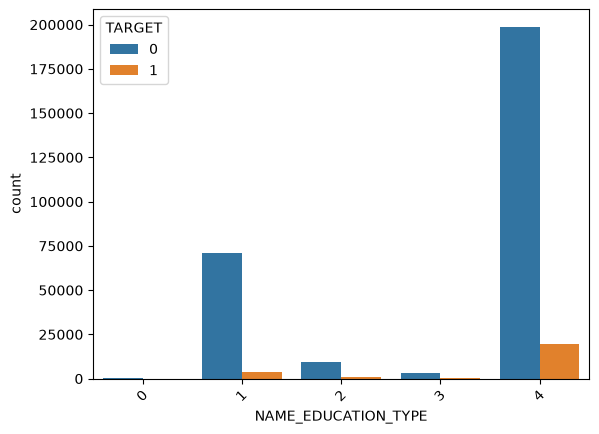

In [39]:
# Education vs Default
sns.countplot(x='NAME_EDUCATION_TYPE', hue='TARGET', data=df)
plt.xticks(rotation=45)

### Observation

- Applicants with secondary and higher education levels represent the majority of loan applications.
- Default patterns vary across education categories.
- Individuals with higher educational qualifications generally tend to have more stable employment and income sources.
- Education level appears to be a potentially important factor influencing loan repayment behavior.

In [40]:
corr_target = df.corr(numeric_only=True)['TARGET'].sort_values(ascending=False)

print(corr_target.head(10))
print(corr_target.tail(10))

TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
NAME_EDUCATION_TYPE            0.054699
CODE_GENDER                    0.054692
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
NAME_INCOME_TYPE               0.046829
Name: TARGET, dtype: float64
REGION_POPULATION_RELATIVE   -0.037227
FLOORSMAX_MODE               -0.038377
FLOORSMAX_MEDI               -0.039157
FLOORSMAX_AVG                -0.039385
AMT_GOODS_PRICE              -0.039623
DAYS_EMPLOYED                -0.044932
AGE_YEARS                    -0.078239
EXT_SOURCE_1                 -0.098887
EXT_SOURCE_3                 -0.155892
EXT_SOURCE_2                 -0.160295
Name: TARGET, dtype: float64


### Correlation Analysis

- Correlation analysis was performed to identify variables most associated with loan default.
- Most individual variables showed weak correlations with the target variable.
- This suggests that loan default prediction depends on the combined effect of multiple demographic and financial features rather than a single dominant factor.

# EDA Summary

1. The dataset is highly imbalanced, with approximately 92% non-defaulters and 8% defaulters.

2. Income and credit-related variables exhibit significant positive skewness and contain outliers.

3. Most applicants belong to the middle-age working population.

4. Educational qualification, income source, and demographic characteristics show noticeable variation in default behavior.

5. No individual feature demonstrates a strong correlation with loan default, indicating that multiple variables must be considered together for effective prediction.

6. Financial and demographic features collectively provide useful information for identifying potential defaulters.

# Model Building

In [41]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [42]:
print(X.shape)
print(y.shape)

(307511, 105)
(307511,)


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
print(X_train.shape)
print(X_test.shape)

(246008, 105)
(61503, 105)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [47]:
y_pred_lr = lr.predict(X_test_scaled)

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6886981122872055
Precision: 0.16010737740280906
Recall: 0.6727089627391742
F1 Score: 0.2586540695423217
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [56]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight= 'balanced'
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [57]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

Accuracy: 0.6577077540932963
Precision: 0.1427492782589385
Recall: 0.6473313192346425
F1 Score: 0.2339155749636099


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [55]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9169308814204186
Precision: 0.3962536023054755
Recall: 0.0553877139979859
F1 Score: 0.09719031631030217


# With SMOTE

In [59]:
from imblearn.over_sampling import SMOTE

In [60]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [61]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE:
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [62]:
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)

g:\HomeLoneDEF\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
g:\HomeLoneDEF\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [63]:
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)

g:\HomeLoneDEF\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
g:\HomeLoneDEF\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Accuracy: 0.4818138952571419
Precision: 0.08942469098122997
Recall: 0.5901309164149043
F1 Score: 0.1553140736814206

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.47      0.63     56538
           1       0.09      0.59      0.16      4965

    accuracy                           0.48     61503
   macro avg       0.51      0.53      0.39     61503
weighted avg       0.86      0.48      0.59     61503



# SMOTE Experiment

To address class imbalance, the SMOTE oversampling technique was applied to the training dataset.

However, the resulting model showed lower overall performance compared to the original Logistic Regression model. While SMOTE increased the number of minority class samples, it reduced the model's precision, accuracy, and F1-score.

Therefore, the Logistic Regression model with class_weight='balanced' was retained as the final model.

In [65]:
from sklearn.metrics import roc_auc_score

y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_smote)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.55412557327163


g:\HomeLoneDEF\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


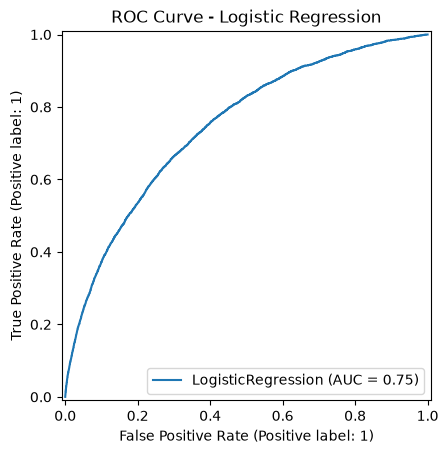

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    lr,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

## Model Comparison Report

Four models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, and Logistic Regression with SMOTE.

| Model                       | Accuracy | Recall | F1 Score |
| --------------------------- | -------- | ------ | -------- |
| Logistic Regression         | 68.87%   | 67.27% | 25.87%   |
| Decision Tree               | 65.77%   | 64.73% | 23.39%   |
| Random Forest               | 91.69%   | 5.54%  | 9.72%    |
| Logistic Regression (SMOTE) | 48.18%   | 59.01% | 15.53%   |

Although Random Forest achieved the highest accuracy, its recall was very low. Logistic Regression achieved the highest recall and F1-score, making it the best model for identifying loan defaulters.

**Recommended Model:** Logistic Regression


## Challenges Faced

* The dataset contained many missing values, which were handled using column removal and imputation techniques.
* The target variable was highly imbalanced (92% non-defaulters and 8% defaulters).
* Income and credit-related features contained outliers.
* Accuracy alone was misleading because of class imbalance, so Recall and F1-score were used for model evaluation.
* Multiple models were tested to select the most suitable model for loan default prediction.
